<a href="https://colab.research.google.com/github/ParusSlava/melbourne-housing/blob/main/notebook/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


# Крок 1. Завантаження даних

In [23]:
RAW_URL = 'https://raw.githubusercontent.com/ParusSlava/melbourne-housing/refs/heads/main/data/melb_data.csv'

df_origin = pd.read_csv(RAW_URL)

In [24]:

df = df_origin.copy()

# Крок 2. Перший огляд

In [25]:
df.shape

(13580, 21)

In [26]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [32]:
df.describe().round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [33]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2',
       'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount'],
      dtype='object')

In [38]:
clean = df.copy()
if 'Unnamed: 0' in df.columns:
    clean = clean.drop(columns = ['Unnamed: 0'])
    print('Column with index - deleted')


# Крок 3. Очищення

In [39]:
# Конвертуємо дату
print("Тип до:", df["Date"].dtype)
print("Приклади значень:", df["Date"].head(3).tolist())

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print("Тип після:", df["Date"].dtype)
print("Діапазон дат:", df["Date"].min(), "—", df["Date"].max())

Тип до: object
Приклади значень: ['3/12/2016', '4/02/2016', '4/03/2017']
Тип після: datetime64[ns]
Діапазон дат: 2016-01-28 00:00:00 — 2017-09-23 00:00:00


In [41]:
# Замінюємо нулі на "немає даних"
print("Нулів у Landsize до:", (df["Landsize"] == 0).sum())
print("Нулів у BuildingArea до:", (df["BuildingArea"] == 0).sum())

for col in ["Landsize", "BuildingArea"]:
    df.loc[df[col] == 0, col] = np.nan

print("Нулів у Landsize після:", (df["Landsize"] == 0).sum())
print("Нулів у BuildingArea після:", (df["BuildingArea"] == 0).sum())

Нулів у Landsize до: 0
Нулів у BuildingArea до: 0
Нулів у Landsize після: 0
Нулів у BuildingArea після: 0


In [43]:
# Виправляємо неможливі роки
print("Мінімальний рік:", df["YearBuilt"].min())
print("\nЗначення < 1840:")
print(df[df["YearBuilt"] < 1840]["YearBuilt"].value_counts())

df.loc[df["YearBuilt"] < 1840, "YearBuilt"] = np.nan

print("\nМінімальний рік після очищення:", df["YearBuilt"].min())

Мінімальний рік: 1850.0

Значення < 1840:
Series([], Name: count, dtype: int64)

Мінімальний рік після очищення: 1850.0


In [44]:
# Перевіряємо дублікати
dupl_count = df.duplicated().sum()
print("Кількість дублікатів:", dupl_count)

if dupl_count > 0:
    df = df.drop_duplicates()
    print("Дублікати видалено. Новий розмір:", df.shape)
else:
    print("Дублікатів немає — все чисто!")

Кількість дублікатів: 0
Дублікатів немає — все чисто!


In [45]:
# Підсумковий звіт про пропуски
print("=== ПРОПУСКИ ПІСЛЯ ОЧИЩЕННЯ ===\n")

missing_report = pd.DataFrame({
    "пропусків_кількість": df.isna().sum(),
    "пропусків_%": (df.isna().mean() * 100).round(1),
}).sort_values("пропусків_%", ascending=False)

missing_report = missing_report[missing_report["пропусків_%"] > 0]
print(missing_report.to_string())

print(f"\nФінальний розмір: {df.shape[0]} рядків × {df.shape[1]} стовпців")

=== ПРОПУСКИ ПІСЛЯ ОЧИЩЕННЯ ===

              пропусків_кількість  пропусків_%
BuildingArea                 6467         47.6
YearBuilt                    5377         39.6
Landsize                     1939         14.3
CouncilArea                  1369         10.1
Car                            62          0.5

Фінальний розмір: 13580 рядків × 21 стовпців


In [46]:
# Зберігаємо очищений файл
df.to_csv("melb_clean.csv", index=False)
print("Файл збережено як melb_clean.csv")
print("Розмір оригіналу:", df_origin.shape)
print("Розмір після очищення:", df.shape)

Файл збережено як melb_clean.csv
Розмір оригіналу: (13580, 21)
Розмір після очищення: (13580, 21)


## Крок 4. Дослідження (EDA)

In [47]:
import numpy as np
import matplotlib.pyplot as plt

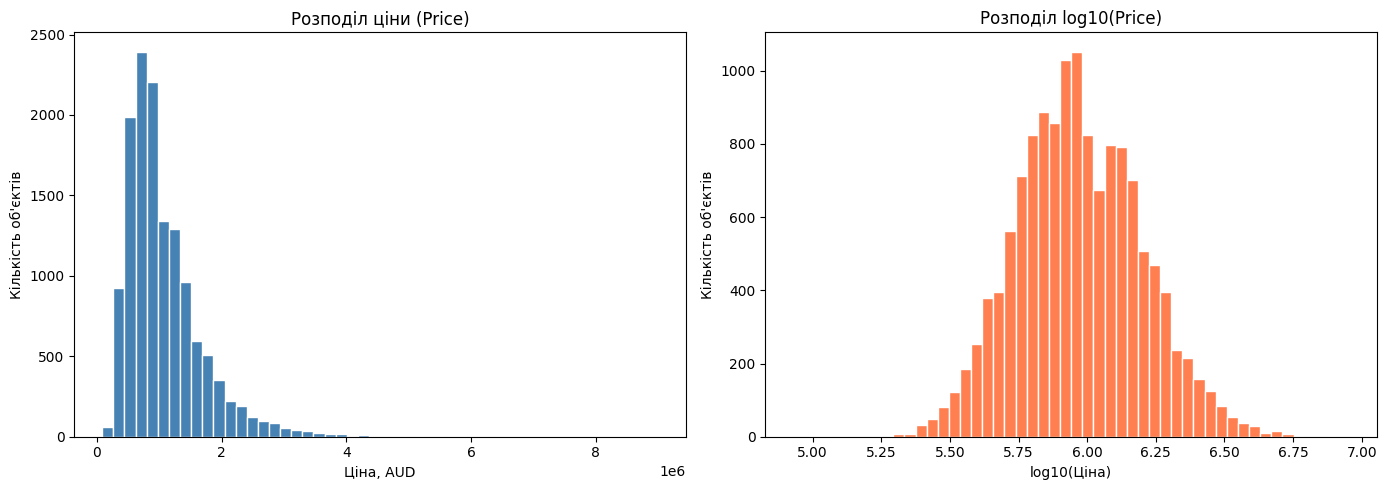

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ліворуч — звичайна ціна
axes[0].hist(df["Price"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Розподіл ціни (Price)")
axes[0].set_xlabel("Ціна, AUD")
axes[0].set_ylabel("Кількість об'єктів")

# Праворуч — логарифм ціни
axes[1].hist(np.log10(df["Price"].dropna()), bins=50, color="coral", edgecolor="white")
axes[1].set_title("Розподіл log10(Price)")
axes[1].set_xlabel("log10(Ціна)")
axes[1].set_ylabel("Кількість об'єктів")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1533/3730790921.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_type, labels=types, patch_artist=True)


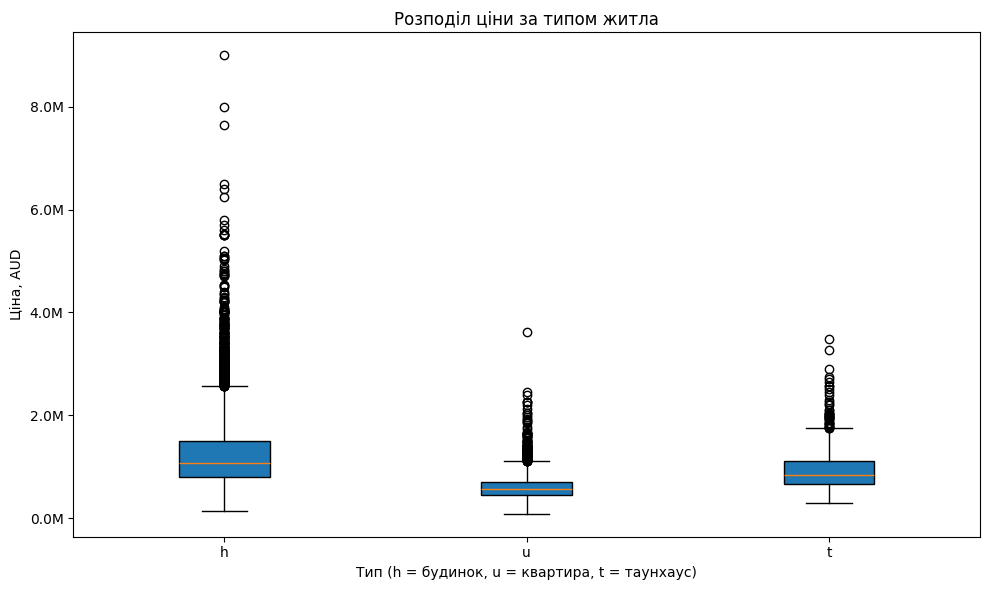

In [49]:
# Ціна за типом житла (boxplot)
fig, ax = plt.subplots(figsize=(10, 6))

# Групуємо дані по типу
types = df["Type"].unique()
data_by_type = [df[df["Type"] == t]["Price"].dropna() for t in types]

ax.boxplot(data_by_type, labels=types, patch_artist=True)
ax.set_title("Розподіл ціни за типом житла")
ax.set_xlabel("Тип (h = будинок, u = квартира, t = таунхаус)")
ax.set_ylabel("Ціна, AUD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

/tmp/ipykernel_1533/1055093206.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_region, labels=regions, patch_artist=True)


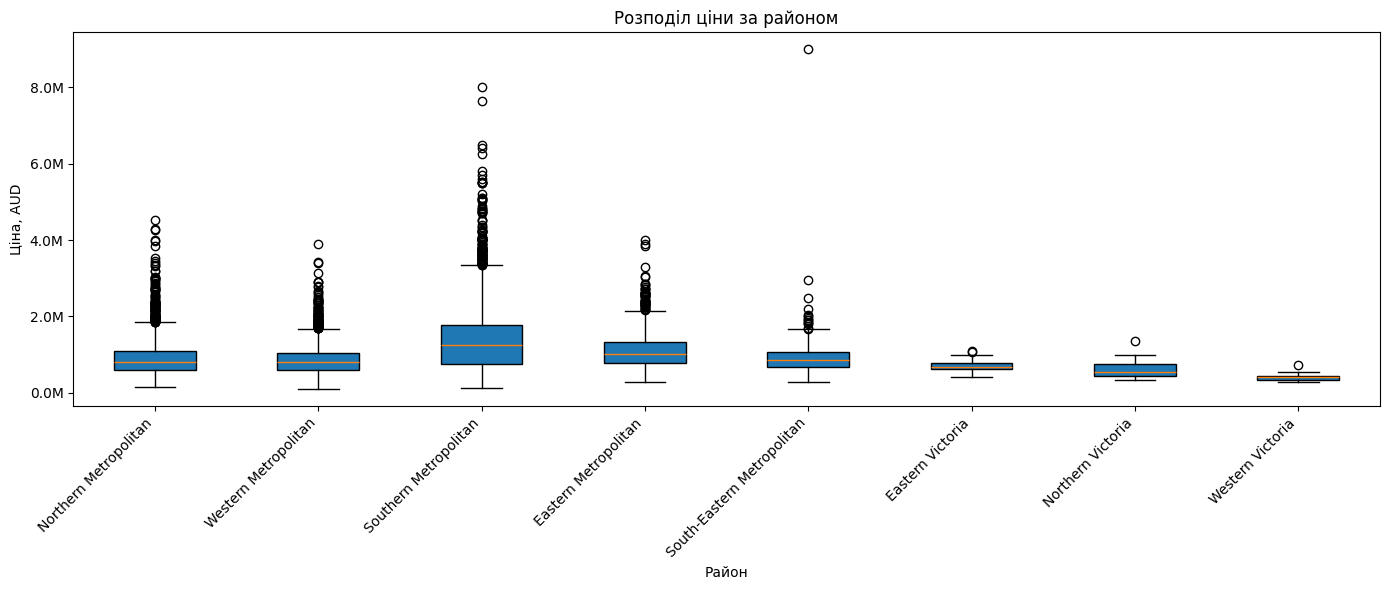

In [50]:
# Ціна за районом (boxplot)
fig, ax = plt.subplots(figsize=(14, 6))

regions = df["Regionname"].dropna().unique()
data_by_region = [df[df["Regionname"] == r]["Price"].dropna() for r in regions]

ax.boxplot(data_by_region, labels=regions, patch_artist=True)
ax.set_title("Розподіл ціни за районом")
ax.set_xlabel("Район")
ax.set_ylabel("Ціна, AUD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

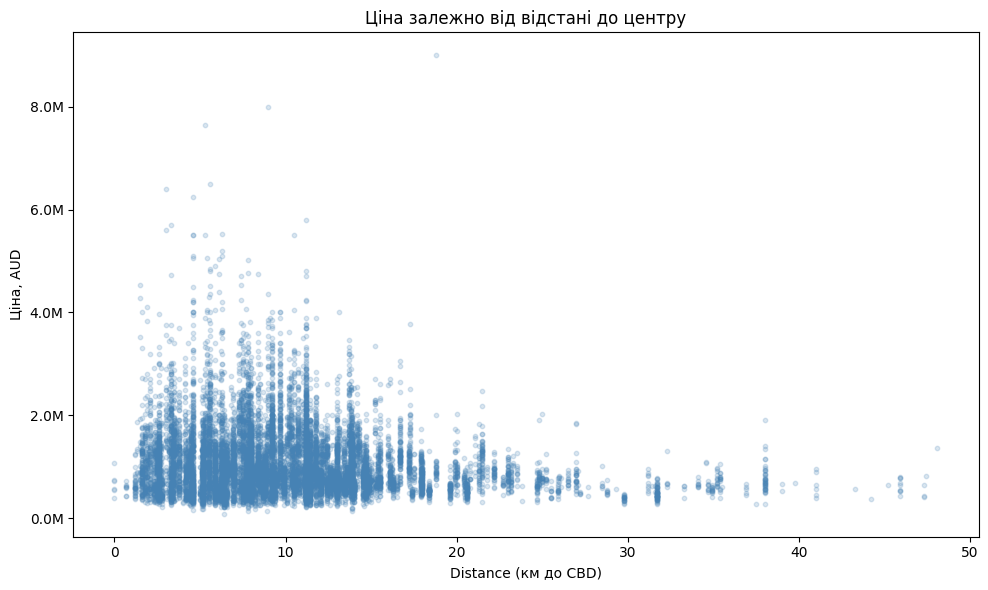

In [51]:
#  Scatter: ціна vs відстань до центру
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df["Distance"], df["Price"], alpha=0.2, s=10, color="steelblue")
ax.set_title("Ціна залежно від відстані до центру")
ax.set_xlabel("Distance (км до CBD)")
ax.set_ylabel("Ціна, AUD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

In [52]:
# Кореляція ознак з ціною
num = df.select_dtypes("number")           # беремо тільки числові стовпці
cor_price = num.corr()["Price"].drop("Price")   # кореляція кожної ознаки з Price

print("=== КОРЕЛЯЦІЯ З ЦІНОЮ ===\n")
print(cor_price.sort_values(key=abs, ascending=False).round(3))

=== КОРЕЛЯЦІЯ З ЦІНОЮ ===

Rooms            0.497
Bedroom2         0.476
Bathroom         0.467
YearBuilt       -0.332
Car              0.239
Lattitude       -0.213
Longtitude       0.204
Distance        -0.163
Postcode         0.108
BuildingArea     0.092
Propertycount   -0.042
Landsize         0.023
Name: Price, dtype: float64


In [53]:
# Пошук ознак-дублікатів
cm = num.corr().abs()   # матриця кореляцій (всі значення > 0)

print("=== КОРЕЛЯЦІЯ МІЖ ОЗНАКАМИ ===\n")
print(cm.round(2))

# Шукаємо пари з |r| > 0.9 (майже-дублікати)
print("\n=== ПАРИ З |r| > 0.9 ===\n")
for col in cm.columns:
    for row in cm.index:
        if col != row and cm.loc[row, col] > 0.9:
            print(f"{row} ↔ {col}: {cm.loc[row, col]:.3f}")

# Окремо — Rooms vs Bedroom2
print(f"\nRooms ↔ Bedroom2: {cm.loc['Rooms', 'Bedroom2']:.3f}")

=== КОРЕЛЯЦІЯ МІЖ ОЗНАКАМИ ===

               Rooms  Price  Distance  Postcode  Bedroom2  Bathroom   Car  Landsize  BuildingArea  YearBuilt  \
Rooms           1.00   0.50      0.29      0.06      0.94      0.59  0.41      0.00          0.12       0.07   
Price           0.50   1.00      0.16      0.11      0.48      0.47  0.24      0.02          0.09       0.33   
Distance        0.29   0.16      1.00      0.43      0.30      0.13  0.26      0.01          0.10       0.25   
Postcode        0.06   0.11      0.43      1.00      0.06      0.11  0.05      0.03          0.06       0.03   
Bedroom2        0.94   0.48      0.30      0.06      1.00      0.58  0.41      0.00          0.12       0.05   
Bathroom        0.59   0.47      0.13      0.11      0.58      1.00  0.32      0.03          0.11       0.15   
Car             0.41   0.24      0.26      0.05      0.41      0.32  1.00      0.02          0.10       0.11   
Landsize        0.00   0.02      0.01      0.03      0.00      0.03  0.0

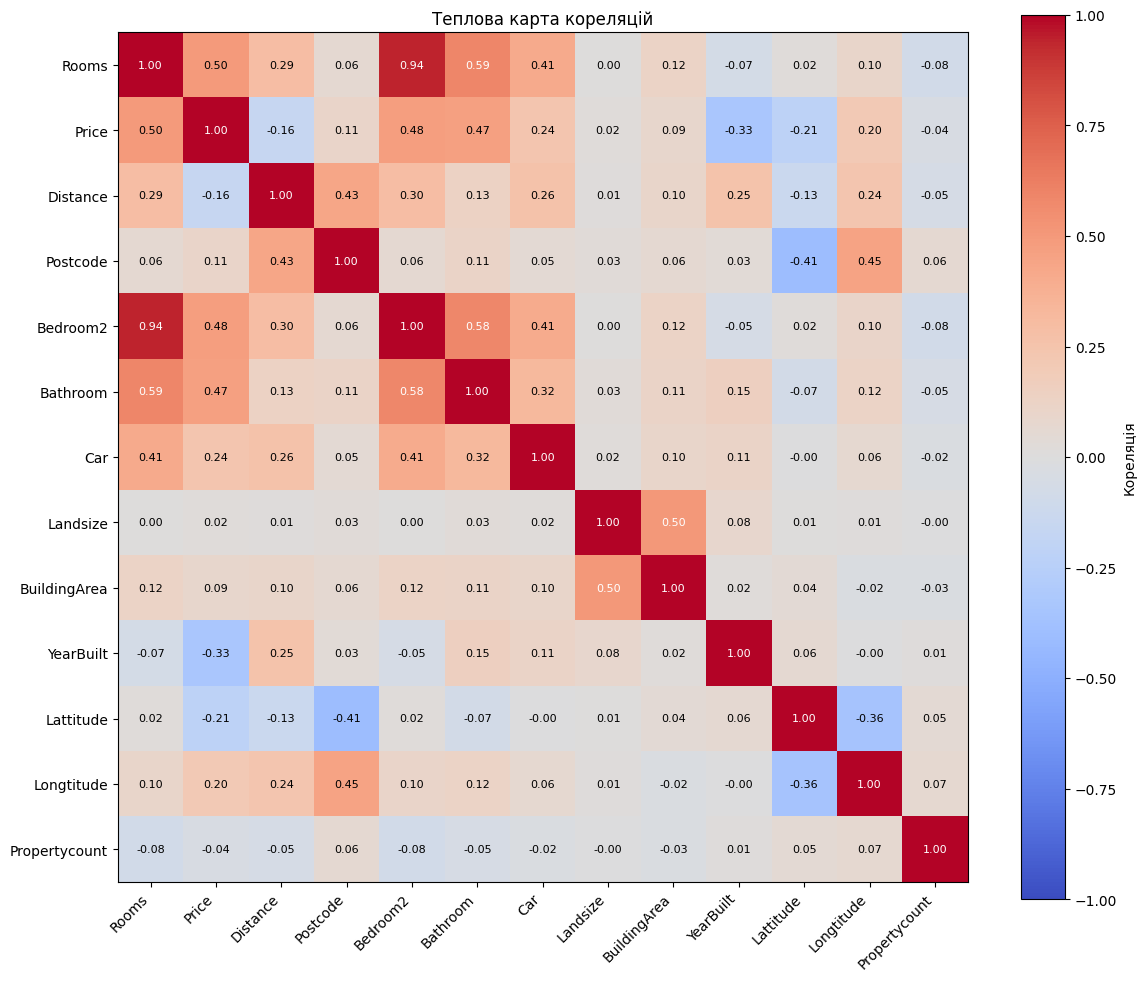

In [54]:
# Теплова карта кореляцій (для наочності)
fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = num.corr()
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Підписи осей
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# Числа у клітинках
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, label="Кореляція")
ax.set_title("Теплова карта кореляцій")
plt.tight_layout()
plt.show()

## Крок 5. Нові ознаки (feature engineering)

In [55]:
# Робимо копію для цього кроку
fe = df.copy()
print("Копію створено. Розмір:", fe.shape)

Копію створено. Розмір: (13580, 21)


In [56]:
# Ознаки з дати продажу
fe["sale_year"]  = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

print(fe[["Date", "sale_year", "sale_month"]].head())

        Date  sale_year  sale_month
0 2016-12-03       2016          12
1 2016-02-04       2016           2
2 2017-03-04       2017           3
3 2017-03-04       2017           3
4 2016-06-04       2016           6


In [57]:
# Вік будинку на момент продажу
fe["age"] = fe["sale_year"] - fe["YearBuilt"]

# Перевіряємо результат
print(fe[["sale_year", "YearBuilt", "age"]].dropna().head(10))
print("\nСтатистика age:")
print(fe["age"].describe().round(1))

    sale_year  YearBuilt    age
1        2016     1900.0  116.0
2        2017     1900.0  117.0
4        2016     2014.0    2.0
6        2016     1910.0  106.0
7        2016     1890.0  126.0
9        2016     1900.0  116.0
11       2016     2005.0   11.0
12       2016     2009.0    7.0
15       2016     1890.0  126.0
16       2016     1880.0  136.0

Статистика age:
count    8203.0
mean       51.7
std        36.2
min        -2.0
25%        17.0
50%        47.0
75%        76.0
max       167.0
Name: age, dtype: float64


In [58]:
# Прапорці наявності даних
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"]    = fe["YearBuilt"].notna().astype(int)
fe["has_landsize"]     = fe["Landsize"].notna().astype(int)

# Перевіряємо скільки одиниць і нулів
print("has_buildingarea:", fe["has_buildingarea"].value_counts().to_dict())
print("has_yearbuilt:   ", fe["has_yearbuilt"].value_counts().to_dict())
print("has_landsize:    ", fe["has_landsize"].value_counts().to_dict())

has_buildingarea: {1: 7113, 0: 6467}
has_yearbuilt:    {1: 8203, 0: 5377}
has_landsize:     {1: 11641, 0: 1939}


In [59]:
# Кодування району через частоту
# Рахуємо як часто зустрічається кожен suburb
suburb_counts = fe["Suburb"].value_counts()
print("Кількість унікальних Suburb:", fe["Suburb"].nunique())
print("\nТоп-5 найчастіших:")
print(suburb_counts.head())

# Створюємо ознаку — частота цього suburb у датасеті
fe["suburb_freq"] = fe["Suburb"].map(suburb_counts)

print("\nПриклад результату:")
print(fe[["Suburb", "suburb_freq"]].head(10))

Кількість унікальних Suburb: 314

Топ-5 найчастіших:
Suburb
Reservoir         359
Richmond          260
Bentleigh East    249
Preston           239
Brunswick         222
Name: count, dtype: int64

Приклад результату:
       Suburb  suburb_freq
0  Abbotsford           56
1  Abbotsford           56
2  Abbotsford           56
3  Abbotsford           56
4  Abbotsford           56
5  Abbotsford           56
6  Abbotsford           56
7  Abbotsford           56
8  Abbotsford           56
9  Abbotsford           56


In [60]:
# Видаляємо зайві стовпці
cols_to_drop = [
    "Date",        # вже витягли рік і місяць
    "YearBuilt",   # вже порахували age
    "Suburb",      # вже закодували через suburb_freq
    "Address",     # унікальний текст, не несе корисної інформації для моделі
]

fe = fe.drop(columns=cols_to_drop)

print("Стовпці після видалення зайвих:")
print(fe.columns.tolist())
print("\nРозмір:", fe.shape)

Стовпці після видалення зайвих:
['Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'sale_year', 'sale_month', 'age', 'has_buildingarea', 'has_yearbuilt', 'has_landsize', 'suburb_freq']

Розмір: (13580, 24)


In [61]:
# Фінальний огляд нових ознак
print("=== НОВІ ОЗНАКИ ===\n")
new_cols = ["sale_year", "sale_month", "age",
            "has_buildingarea", "has_yearbuilt", "has_landsize",
            "suburb_freq"]

print(fe[new_cols].describe().round(1))
print("\nПропуски у нових ознаках:")
print(fe[new_cols].isna().sum())

=== НОВІ ОЗНАКИ ===

       sale_year  sale_month     age  has_buildingarea  has_yearbuilt  has_landsize  suburb_freq
count    13580.0     13580.0  8203.0           13580.0        13580.0       13580.0      13580.0
mean      2016.5         7.1    51.7               0.5            0.6           0.9        113.3
std          0.5         2.5    36.2               0.5            0.5           0.3         78.7
min       2016.0         1.0    -2.0               0.0            0.0           0.0          1.0
25%       2016.0         5.0    17.0               0.0            0.0           1.0         51.0
50%       2017.0         7.0    47.0               1.0            1.0           1.0        102.0
75%       2017.0         9.0    76.0               1.0            1.0           1.0        162.0
max       2017.0        12.0   167.0               1.0            1.0           1.0        359.0

Пропуски у нових ознаках:
sale_year              0
sale_month             0
age                 5377
has_

In [62]:
# Зберігаємо результат
fe.to_csv("melb_features.csv", index=False)
print("Файл збережено як melb_features.csv")
print("Фінальний розмір:", fe.shape)
print("\nВсі стовпці:")
for col in fe.columns:
    print(f"  {col}")

Файл збережено як melb_features.csv
Фінальний розмір: (13580, 24)

Всі стовпці:
  Rooms
  Type
  Price
  Method
  SellerG
  Distance
  Postcode
  Bedroom2
  Bathroom
  Car
  Landsize
  BuildingArea
  CouncilArea
  Lattitude
  Longtitude
  Regionname
  Propertycount
  sale_year
  sale_month
  age
  has_buildingarea
  has_yearbuilt
  has_landsize
  suburb_freq
